# STUDY UNIVERSE FORMATION

In [1]:
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from branca.element import MacroElement, Template
from shapely.geometry import box
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "1) DATA AND TERRITORIAL STRATIFICATION",
]
notebook_dir = next((path for path in candidate_dirs if (path / "Data").exists()), None)
if notebook_dir is None:
    raise FileNotFoundError("Could not locate the notebook Data directory.")
notebook_dir = notebook_dir.resolve()

data_dir = notebook_dir / "Data"
output_dir = notebook_dir / "Outputs"
map_dir = output_dir / "InteractiveMaps"
universe_dir = data_dir / "Universe"

populated_centers_path = data_dir / "PopulatedCenters" / "CCPP2017.shp"
departments_path = data_dir / "Departments" / "DEPARTAMENTO.shp"
populated_grid_path = universe_dir / "grid_peru_con_cp.shp"
grid_embeddings_path = data_dir / "GridEmbeddings" / "grid_embeddings_2025_mean_std.csv"
obtained_areas_path = data_dir / "ObtainedAreas" / "obtained_areas.gpkg"

cell_size_m = 18_000
random_state = 0
cluster_count = 9
k_values = range(6, 16)

universe_dir.mkdir(parents=True, exist_ok=True)
map_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# Load populated centers.
populated_centers = gpd.read_file(populated_centers_path)

<Axes: >

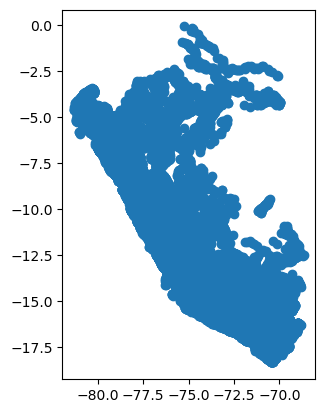

In [3]:
populated_centers.plot()

In [4]:
# Load Peru's administrative departments.
departments = gpd.read_file(departments_path)

<Axes: >

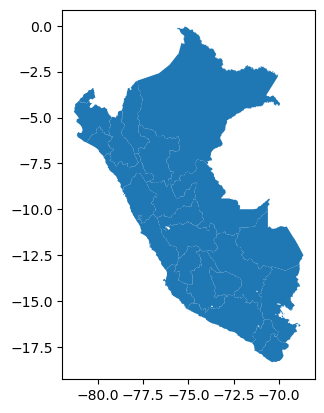

In [5]:
departments.plot()

Creating and filtering 18 x 18 km cells that contain at least one populated center. The cell size follows the approximate average footprint size of the PeruSAT-1 images used in the study.

Metric CRS used: EPSG:32718
Total generated cells: 8814
Cells intersecting Peru: 4255
Cells with at least one populated center: 2818


<Axes: >

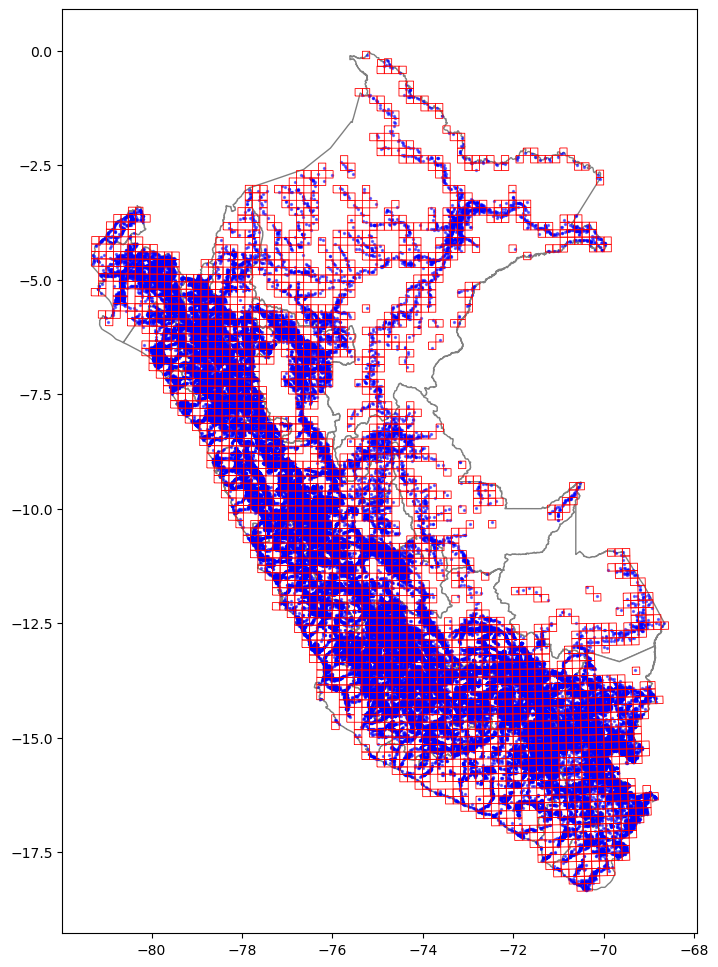

In [6]:
# ============================================================
# 1) Minimum Input Validation
# ============================================================
assert isinstance(departments, gpd.GeoDataFrame), "departments must be a GeoDataFrame"
assert isinstance(populated_centers, gpd.GeoDataFrame), "populated_centers must be a GeoDataFrame"

if departments.crs is None:
    raise ValueError("departments does not have a defined CRS")
if populated_centers.crs is None:
    raise ValueError("populated_centers does not have a defined CRS")

# ============================================================
# 2) Peru Boundary From Department Polygons
# ============================================================
peru_geometry = departments.union_all()
peru_boundary = gpd.GeoDataFrame({"name": ["Peru"]}, geometry=[peru_geometry], crs=departments.crs)

# ============================================================
# 3) Metric CRS For The 18 x 18 km Grid
# ============================================================
metric_crs = peru_boundary.estimate_utm_crs()
print("Metric CRS used:", metric_crs)

peru_metric = peru_boundary.to_crs(metric_crs)
populated_centers_metric = populated_centers.to_crs(metric_crs)

# ============================================================
# 4) Create A Non-Overlapping 18 x 18 km Grid
# ============================================================
minx, miny, maxx, maxy = peru_metric.total_bounds

x_coordinates = np.arange(minx, maxx, cell_size_m)
y_coordinates = np.arange(miny, maxy, cell_size_m)

grid_cells = []
grid_ids = []
next_grid_id = 0

for x in x_coordinates:
    for y in y_coordinates:
        grid_cells.append(box(x, y, x + cell_size_m, y + cell_size_m))
        grid_ids.append(next_grid_id)
        next_grid_id += 1

grid = gpd.GeoDataFrame(
    {"grid_id": grid_ids},
    geometry=grid_cells,
    crs=metric_crs,
)

# ============================================================
# 5) Keep Cells That Intersect Peru
# ============================================================
peru_grid = gpd.sjoin(
    grid,
    peru_metric[["geometry"]],
    how="inner",
    predicate="intersects",
).drop(columns=["index_right"]).drop_duplicates(subset="grid_id")

# ============================================================
# 6) Keep Cells With At Least One Populated Center
#    The 'within' predicate excludes points located exactly on cell borders.
# ============================================================
populated_center_grid_join = gpd.sjoin(
    populated_centers_metric[["geometry"]],
    peru_grid[["grid_id", "geometry"]],
    how="inner",
    predicate="within",
)

grid_ids_with_populated_centers = populated_center_grid_join["grid_id"].unique()

populated_peru_grid = peru_grid[
    peru_grid["grid_id"].isin(grid_ids_with_populated_centers)
].copy()

print("Total generated cells:", len(grid))
print("Cells intersecting Peru:", len(peru_grid))
print("Cells with at least one populated center:", len(populated_peru_grid))

# ============================================================
# 7) Return To The Original CRS For Plotting
# ============================================================
populated_peru_grid_original_crs = populated_peru_grid.to_crs(departments.crs)

# Quick visualization.
ax = departments.plot(figsize=(10, 12), color="white", edgecolor="gray")
populated_peru_grid_original_crs.boundary.plot(ax=ax, linewidth=0.6, color="red")
populated_centers.plot(ax=ax, markersize=2, color="blue", alpha=0.5)

Exporting the populated 18 x 18 km grid used as the spatial universe.

In [7]:
# Export and reload the populated grid so the shared file matches the notebook output.
populated_peru_grid.to_file(populated_grid_path)
populated_peru_grid = gpd.read_file(populated_grid_path)
populated_peru_grid.plot()

PermissionError: [WinError 32] El proceso no tiene acceso al archivo porque está siendo utilizado por otro proceso: 'D:\\buildings\\INEI-ANALYZER\\1) DATA AND TERRITORIAL STRATIFICATION\\Data\\Universe\\grid_peru_con_cp.shp'

In [ ]:
populated_peru_grid

,grid_id,geometry
0,80,"POLYGON ((-185260.79 9404768.912, -203260.79 9..."
1,84,"POLYGON ((-185260.79 9476768.912, -203260.79 9..."
2,85,"POLYGON ((-185260.79 9494768.912, -203260.79 9..."
3,86,"POLYGON ((-185260.79 9512768.912, -203260.79 9..."
4,87,"POLYGON ((-185260.79 9530768.912, -203260.79 9..."
...,...,...
2813,8514,"POLYGON ((1164739.21 8666768.912, 1146739.21 8..."
2814,8613,"POLYGON ((1182739.21 8414768.912, 1164739.21 8..."
2815,8623,"POLYGON ((1182739.21 8594768.912, 1164739.21 8..."
2816,8624,"POLYGON ((1182739.21 8612768.912, 1164739.21 8..."


# EMBEDDING EXTRACTION

Grid-level characterization using Satellite Embedding V1

The territorial grid cells were characterized using the annual **Satellite Embedding V1** dataset available in Google Earth Engine. This process was performed in the Google Earth Engine Code Editor.

First, the annual embedding image for 2025 was filtered over the spatial extent of the grid containing populated centers. Then, for each grid cell, the mean and standard deviation of all valid pixel values were calculated for each of the 64 embedding bands. As a result, each cell was represented by a 128-dimensional feature vector, composed of 64 mean values and 64 standard deviation values. These variables were later used as input features for the clustering process.

```javascript
var embeddings = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL');

// Use the satellite basemap
Map.setOptions('SATELLITE');

// Load the grid containing populated centers
var geometry = ee.FeatureCollection(
  "projects/inei-buildings-2026/assets/grid_peru_con_cp"
);

Map.centerObject(geometry, 12);

// Define the year of analysis
var year = 2025;
var startDate = ee.Date.fromYMD(year, 1, 1);
var endDate = startDate.advance(1, 'year');

// Filter the annual Satellite Embedding image collection
var filteredEmbeddings = embeddings
  .filter(ee.Filter.date(startDate, endDate))
  .filter(ee.Filter.bounds(geometry));

// Convert the filtered collection into a single image
var embeddingsImage = filteredEmbeddings.mosaic();

print('Satellite Embedding Image', embeddingsImage);

// Visualization parameters
var visParams = {
  min: -0.3,
  max: 0.3,
  bands: ['A01', 'A16', 'A09']
};

Map.addLayer(
  embeddingsImage.clip(geometry),
  visParams,
  'Embeddings Image'
);

// Define reducer: mean and standard deviation
var reducer = ee.Reducer.mean().combine({
  reducer2: ee.Reducer.stdDev(),
  sharedInputs: true
});

// Compute zonal statistics for each grid cell
var gridStats = embeddingsImage.reduceRegions({
  collection: geometry,
  reducer: reducer,
  scale: 10,
  tileScale: 8
});

// Export the resulting table
Export.table.toDrive({
  collection: gridStats,
  description: 'grid_embeddings_2025_mean_std',
  fileFormat: 'CSV'
});
```


In [10]:
grid_embeddings = pd.read_csv(grid_embeddings_path, index_col=0)

In [11]:
grid_embeddings.head()

,A00_mean,A00_stdDev,A01_mean,A01_stdDev,A02_mean,A02_stdDev,A03_mean,A03_stdDev,A04_mean,A04_stdDev,...,A60_mean,A60_stdDev,A61_mean,A61_stdDev,A62_mean,A62_stdDev,A63_mean,A63_stdDev,grid_id,.geo
system:index,,,,,,,,,,,,,,,,,,,,,
00000000000000000000,-0.043307,0.018073,-0.079618,0.023307,-0.165177,0.021389,-0.129150,0.012487,-0.065437,0.028614,...,0.189906,0.024391,-0.215466,0.020215,0.018011,0.018529,0.192798,0.045159,80,"{""type"":""Polygon"",""coordinates"":[[[-81.1732198..."
00000000000000000001,-0.095379,0.047398,0.052787,0.091780,-0.042606,0.064190,-0.040737,0.065923,-0.165021,0.066182,...,0.119542,0.044373,-0.119968,0.082189,-0.022336,0.062678,-0.071696,0.131873,84,"{""type"":""Polygon"",""coordinates"":[[[-81.1670986..."
00000000000000000002,-0.085807,0.053049,0.052026,0.105114,-0.056152,0.065911,-0.076801,0.066129,-0.157777,0.075344,...,0.117024,0.059523,-0.147645,0.073391,-0.018340,0.062647,-0.046019,0.155127,85,"{""type"":""Polygon"",""coordinates"":[[[-81.1656928..."
00000000000000000003,-0.062927,0.049608,0.006034,0.099583,-0.095768,0.058918,-0.077766,0.073368,-0.116729,0.067609,...,0.143244,0.052585,-0.148766,0.078950,0.015688,0.041801,0.025039,0.157623,86,"{""type"":""Polygon"",""coordinates"":[[[-81.1643366..."
00000000000000000004,-0.015332,0.015796,-0.074872,0.019129,-0.138516,0.016993,-0.124856,0.013004,-0.061265,0.016474,...,0.183920,0.010585,-0.194611,0.011386,0.040881,0.011723,0.174440,0.030628,87,"{""type"":""Polygon"",""coordinates"":[[[-81.1630303..."


# CLUSTER FORMATION

In [12]:
embedding_feature_columns = [
    column for column in grid_embeddings.columns
    if column.startswith("A") and (column.endswith("_mean") or column.endswith("_stdDev"))
]
embedding_features = grid_embeddings[embedding_feature_columns]

In [13]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(embedding_features)

c:\Users\decg109\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
c:\Users\decg109\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
c:\Users\decg109\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
c:\Users\decg109\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py

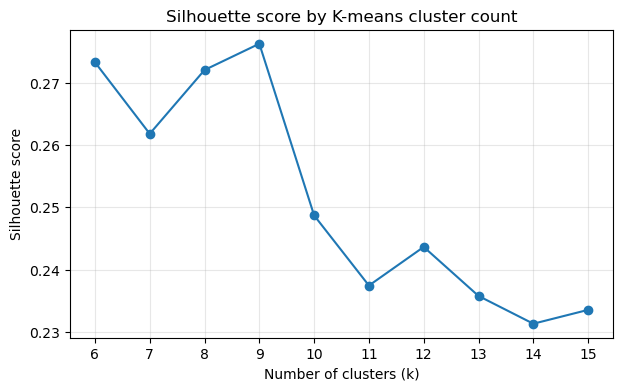

In [13]:
silhouette_scores = []
for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    cluster_labels = kmeans_model.fit_predict(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, cluster_labels))

plt.figure(figsize=(7, 4))
plt.xticks(list(k_values))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score by K-means cluster count")
plt.grid(alpha=0.3)
plt.show()

In [14]:
# The silhouette figure suggests fewer groups, but k=9 keeps more territorial granularity for the study.
kmeans_model = KMeans(n_clusters=cluster_count, random_state=random_state, n_init=10)
cluster_labels = kmeans_model.fit_predict(scaled_features)

c:\Users\decg109\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


In [16]:
grid_embeddings["cluster_id"] = cluster_labels

In [17]:
clustered_grid = populated_peru_grid.join(
    grid_embeddings[["grid_id", "cluster_id"]].set_index("grid_id"),
    on="grid_id",
)

In [19]:
clustered_grid

,grid_id,geometry,cluster_id
80,80,"POLYGON ((-185260.79 9404768.912, -185260.79 9...",2
84,84,"POLYGON ((-185260.79 9476768.912, -185260.79 9...",3
85,85,"POLYGON ((-185260.79 9494768.912, -185260.79 9...",8
86,86,"POLYGON ((-185260.79 9512768.912, -185260.79 9...",8
87,87,"POLYGON ((-185260.79 9530768.912, -185260.79 9...",2
...,...,...,...
8514,8514,"POLYGON ((1164739.21 8666768.912, 1164739.21 8...",2
8613,8613,"POLYGON ((1182739.21 8414768.912, 1182739.21 8...",6
8623,8623,"POLYGON ((1182739.21 8594768.912, 1182739.21 8...",2
8624,8624,"POLYGON ((1182739.21 8612768.912, 1182739.21 8...",2


In [20]:
# Build an interactive K-means cluster map and save it outside the notebook.
cluster_map_gdf = clustered_grid.copy()

# Folium works in WGS84.
if cluster_map_gdf.crs is None:
    raise ValueError("cluster_map_gdf does not have a defined CRS")

cluster_map_gdf = cluster_map_gdf.to_crs(epsg=4326)
cluster_map_gdf["cluster_id"] = cluster_map_gdf["cluster_id"].astype(int)

clusters = sorted(cluster_map_gdf["cluster_id"].unique())
cluster_total = len(clusters)

base_colors = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#66c2a5",
    "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
]

if cluster_total <= len(base_colors):
    colors = base_colors[:cluster_total]
else:
    color_palette = plt.get_cmap("tab20", cluster_total)
    colors = [mcolors.to_hex(color_palette(i)) for i in range(cluster_total)]

cluster_color_map = {cluster: colors[index] for index, cluster in enumerate(clusters)}

bounds = cluster_map_gdf.total_bounds  # minx, miny, maxx, maxy
latitude_center = (bounds[1] + bounds[3]) / 2
longitude_center = (bounds[0] + bounds[2]) / 2

cluster_map = folium.Map(
    location=[latitude_center, longitude_center],
    zoom_start=6,
    tiles="CartoDB positron",
)

def cluster_style_function(feature):
    cluster = feature["properties"]["cluster_id"]
    return {
        "fillColor": cluster_color_map.get(cluster, "#808080"),
        "color": "black",
        "weight": 0.3,
        "fillOpacity": 0.65,
    }

def highlight_style_function(feature):
    return {
        "fillOpacity": 0.9,
        "weight": 1.2,
        "color": "black",
    }

tooltip_fields = []
tooltip_aliases = []

if "grid_id" in cluster_map_gdf.columns:
    tooltip_fields.append("grid_id")
    tooltip_aliases.append("Grid ID")

tooltip_fields.append("cluster_id")
tooltip_aliases.append("Cluster")

cluster_tooltip = folium.GeoJsonTooltip(
    fields=tooltip_fields,
    aliases=tooltip_aliases,
    localize=True,
    sticky=False,
    labels=True,
)

folium.GeoJson(
    cluster_map_gdf,
    name="K-means clusters",
    style_function=cluster_style_function,
    highlight_function=highlight_style_function,
    tooltip=cluster_tooltip,
).add_to(cluster_map)

cluster_map.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

legend_items = ""
for cluster, color in cluster_color_map.items():
    legend_items += f"""
    <li><span style='background:{color};
                     width:14px;
                     height:14px;
                     display:inline-block;
                     margin-right:8px;
                     border:1px solid black;'></span>
        Cluster {cluster}
    </li>
    """

legend_html = f"""
{{% macro html(this, kwargs) %}}
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 180px;
    max-height: 300px;
    overflow-y: auto;
    z-index:9999;
    font-size:14px;
    background-color:white;
    border:2px solid grey;
    border-radius:6px;
    padding:10px;
    ">
    <b>K-means Legend</b>
    <ul style="list-style:none; padding-left:0; margin:10px 0 0 0;">
        {legend_items}
    </ul>
</div>
{{% endmacro %}}
"""

legend = MacroElement()
legend._template = Template(legend_html)
cluster_map.get_root().add_child(legend)

cluster_map_path = map_dir / "kmeans_clusters.html"
cluster_map.save(cluster_map_path)
cluster_map_path

WindowsPath('D:/buildings/INEI-ANALYZER/1) DATA AND TERRITORIAL STRATIFICATION/Outputs/InteractiveMaps/kmeans_clusters.html')

Based on this segmentation of the Peruvian territory, each cluster was interpreted through visual inspection using freely available satellite imagery, mainly Google Earth. This allowed the territorial domains generated by the clustering process to be associated with recognizable geographic and environmental characteristics.

| Cluster | Geographic description                                                                                     |
| ------: | ---------------------------------------------------------------------------------------------------------- |
|       0 | Lowland Amazonian regions characterized by large river systems and meanders.                               |
|       1 | Andean regions corresponding to relatively green inter-Andean valleys.                                     |
|       2 | Large and dense areas of deep forest with the presence of smaller hydrological networks.                   |
|       3 | Coastal desert ecosystems and irrigated coastal valleys.                                                   |
|       4 | Equatorial dry forest, representative of the northern coast of the country.                                |
|       5 | Dry and mountainous high-Andean terrain, typical of the Puna geological landscape.                         |
|       6 | Green upper Amazonian region, without the same tree-cover density as the Amazonian lowlands.               |
|       7 | Transitional coastal valleys and arid areas near the Andean foothills, associated with Yunga environments. |
|       8 | Flat coastal strip adjacent to the maritime coastline.                                                     |


# ACQUIRED IMAGES

The final image selection and building delineation process followed a non-probabilistic design. The dataset was constructed using PeruSAT-1 scenes already available in the INEI imagery gallery, complemented by additional scenes requested to ensure coverage of the territorial clusters identified in the previous stage.

In [21]:
footprints = gpd.read_file(obtained_areas_path)

<Axes: >

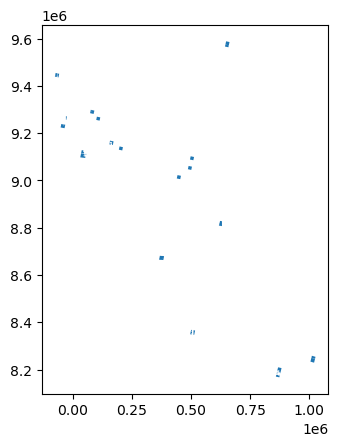

In [22]:
footprints.plot()

In [23]:
# --------------------------------------------------
# 1. Copy Data
# --------------------------------------------------
clusters_gdf = clustered_grid.copy()
footprints_gdf = footprints.copy()

# --------------------------------------------------
# 2. Check CRS
# --------------------------------------------------
if clusters_gdf.crs is None:
    raise ValueError("clusters_gdf does not have a defined CRS")

if footprints_gdf.crs is None:
    raise ValueError("footprints_gdf does not have a defined CRS")

# --------------------------------------------------
# 3. Reproject To An Equal-Area CRS For Intersections And Area Calculation
# --------------------------------------------------
# EPSG:6933 is a global equal-area projection, useful for area calculations.
area_crs = "EPSG:6933"

clusters_equal_area = clusters_gdf.to_crs(area_crs)
footprints_equal_area = footprints_gdf.to_crs(area_crs)

# --------------------------------------------------
# 4. Ensure Valid Geometries
# --------------------------------------------------
clusters_equal_area["geometry"] = clusters_equal_area.geometry.make_valid()
footprints_equal_area["geometry"] = footprints_equal_area.geometry.make_valid()

clusters_equal_area = clusters_equal_area[~clusters_equal_area.geometry.is_empty].copy()
footprints_equal_area = footprints_equal_area[~footprints_equal_area.geometry.is_empty].copy()

# --------------------------------------------------
# 5. Create Unique IDs
# --------------------------------------------------
clusters_equal_area = clusters_equal_area.reset_index(drop=True)
footprints_equal_area = footprints_equal_area.reset_index(drop=True)

clusters_equal_area["cluster_cell_id"] = clusters_equal_area.index
footprints_equal_area["footprint_id"] = footprints_equal_area.index

clusters_equal_area["cluster_id"] = clusters_equal_area["cluster_id"].astype(int)

# --------------------------------------------------
# 6. Spatial Intersection Between Footprints And K-means Cells
# --------------------------------------------------
footprint_cluster_intersections = gpd.overlay(
    footprints_equal_area,
    clusters_equal_area[["cluster_cell_id", "cluster_id", "geometry"]],
    how="intersection",
)

footprint_cluster_intersections["intersection_area_m2"] = footprint_cluster_intersections.geometry.area

footprint_cluster_intersections.head()

,area_m2,footprint_id,cluster_cell_id,cluster_id,geometry,intersection_area_m2
0,2.052938e+08,0,1297,0,"POLYGON ((-7237579.093 -1098368.527, -7237579....",1.543372e+08
1,2.052938e+08,0,1363,0,"POLYGON ((-7235685.851 -1098378.124, -7235686....",4.649166e+05
2,2.052938e+08,0,1364,0,"POLYGON ((-7237553.31 -1098374.919, -7237555.7...",5.065582e+07
3,2.051094e+08,1,1299,0,"POLYGON ((-7237576.15 -1049532.595, -7237576.1...",2.512142e+07
4,2.051094e+08,1,1366,0,"POLYGON ((-7225544.529 -1036712.654, -7225545....",1.539249e+08


In [24]:
# --------------------------------------------------
# 7. Summary By K-means Cluster
# --------------------------------------------------
summary_by_cluster = (
    footprint_cluster_intersections
    .groupby("cluster_id")
    .agg(
        total_intersection_area_m2=("intersection_area_m2", "sum"),
    )
    .reset_index()
)

summary_by_cluster["total_intersection_area_ha"] = (
    summary_by_cluster["total_intersection_area_m2"] / 10_000
)

summary_by_cluster

,cluster_id,total_intersection_area_m2,total_intersection_area_ha
0,0,8.223905e+08,82239.054692
1,1,8.945792e+08,89457.924660
2,2,2.705402e+08,27054.015888
3,3,3.656558e+08,36565.579509
4,4,2.068851e+08,20688.505712
5,5,5.594049e+08,55940.490579
6,6,3.110642e+07,3110.641990
7,7,3.706500e+08,37065.000142
8,8,3.839536e+08,38395.358509


In [25]:
# --------------------------------------------------
# 8. Prepare Data For Folium
# --------------------------------------------------
clusters_plot = clusters_equal_area.to_crs(epsg=4326)
intersections_plot = footprint_cluster_intersections.to_crs(epsg=4326)

# --------------------------------------------------
# 9. Create Color Palette
# --------------------------------------------------
clusters = sorted(clusters_plot["cluster_id"].unique())
cluster_total = len(clusters)

base_colors = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#66c2a5",
    "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
]

if cluster_total <= len(base_colors):
    colors = base_colors[:cluster_total]
else:
    color_palette = plt.get_cmap("tab20", cluster_total)
    colors = [mcolors.to_hex(color_palette(i)) for i in range(cluster_total)]

cluster_color_map = {cluster: colors[index] for index, cluster in enumerate(clusters)}

# --------------------------------------------------
# 10. Create Map
# --------------------------------------------------
bounds = clusters_plot.total_bounds  # minx, miny, maxx, maxy

latitude_center = (bounds[1] + bounds[3]) / 2
longitude_center = (bounds[0] + bounds[2]) / 2

footprint_map = folium.Map(
    location=[latitude_center, longitude_center],
    zoom_start=6,
    tiles="CartoDB positron",
)

# --------------------------------------------------
# 11. Style Functions
# --------------------------------------------------
def cluster_style_function(feature):
    cluster = feature["properties"]["cluster_id"]
    return {
        "fillColor": cluster_color_map.get(cluster, "#808080"),
        "color": "black",
        "weight": 0.4,
        "fillOpacity": 0.25,
    }

def footprint_style_function(feature):
    cluster = feature["properties"]["cluster_id"]
    return {
        "fillColor": cluster_color_map.get(cluster, "#808080"),
        "color": cluster_color_map.get(cluster, "#808080"),
        "weight": 0.7,
        "fillOpacity": 0.75,
    }

def highlight_style_function(feature):
    return {
        "fillOpacity": 0.9,
        "weight": 1.5,
        "color": "black",
    }

# --------------------------------------------------
# 12. Add K-means Grid Cells
# --------------------------------------------------
cluster_tooltip = folium.GeoJsonTooltip(
    fields=["cluster_cell_id", "cluster_id"],
    aliases=["Grid cell ID", "Cluster"],
    localize=True,
    sticky=False,
    labels=True,
)

folium.GeoJson(
    clusters_plot,
    name="K-means grid cells",
    style_function=cluster_style_function,
    highlight_function=highlight_style_function,
    tooltip=cluster_tooltip,
).add_to(footprint_map)

# --------------------------------------------------
# 13. Add Intersected Footprints
# --------------------------------------------------
footprint_tooltip = folium.GeoJsonTooltip(
    fields=["footprint_id", "cluster_id", "intersection_area_m2"],
    aliases=["Footprint ID", "Cluster", "Intersection area (m2)"],
    localize=True,
    sticky=False,
    labels=True,
)

folium.GeoJson(
    intersections_plot,
    name="Acquired image footprints intersected with clusters",
    style_function=footprint_style_function,
    highlight_function=highlight_style_function,
    tooltip=footprint_tooltip,
).add_to(footprint_map)

# --------------------------------------------------
# 14. Add Legend
# --------------------------------------------------
legend_items = ""
for cluster, color in cluster_color_map.items():
    legend_items += f"""
    <li><span style='background:{color};
                     width:14px;
                     height:14px;
                     display:inline-block;
                     margin-right:8px;
                     border:1px solid black;'></span>
        Cluster {cluster}
    </li>
    """

legend_html = f"""
{{% macro html(this, kwargs) %}}
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 190px;
    max-height: 300px;
    overflow-y: auto;
    z-index:9999;
    font-size:14px;
    background-color:white;
    border:2px solid grey;
    border-radius:6px;
    padding:10px;
    ">
    <b>K-means Legend</b>
    <ul style="list-style:none; padding-left:0; margin:10px 0 0 0;">
        {legend_items}
    </ul>
</div>
{{% endmacro %}}
"""

legend = MacroElement()
legend._template = Template(legend_html)
footprint_map.get_root().add_child(legend)

# --------------------------------------------------
# 15. Add Layer Control, Fit Bounds, And Save Map
# --------------------------------------------------
folium.LayerControl(collapsed=False).add_to(footprint_map)

footprint_map.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

footprint_map_path = map_dir / "acquired_image_footprints_by_cluster.html"
footprint_map.save(footprint_map_path)
footprint_map_path

WindowsPath('D:/buildings/INEI-ANALYZER/1) DATA AND TERRITORIAL STRATIFICATION/Outputs/InteractiveMaps/acquired_image_footprints_by_cluster.html')

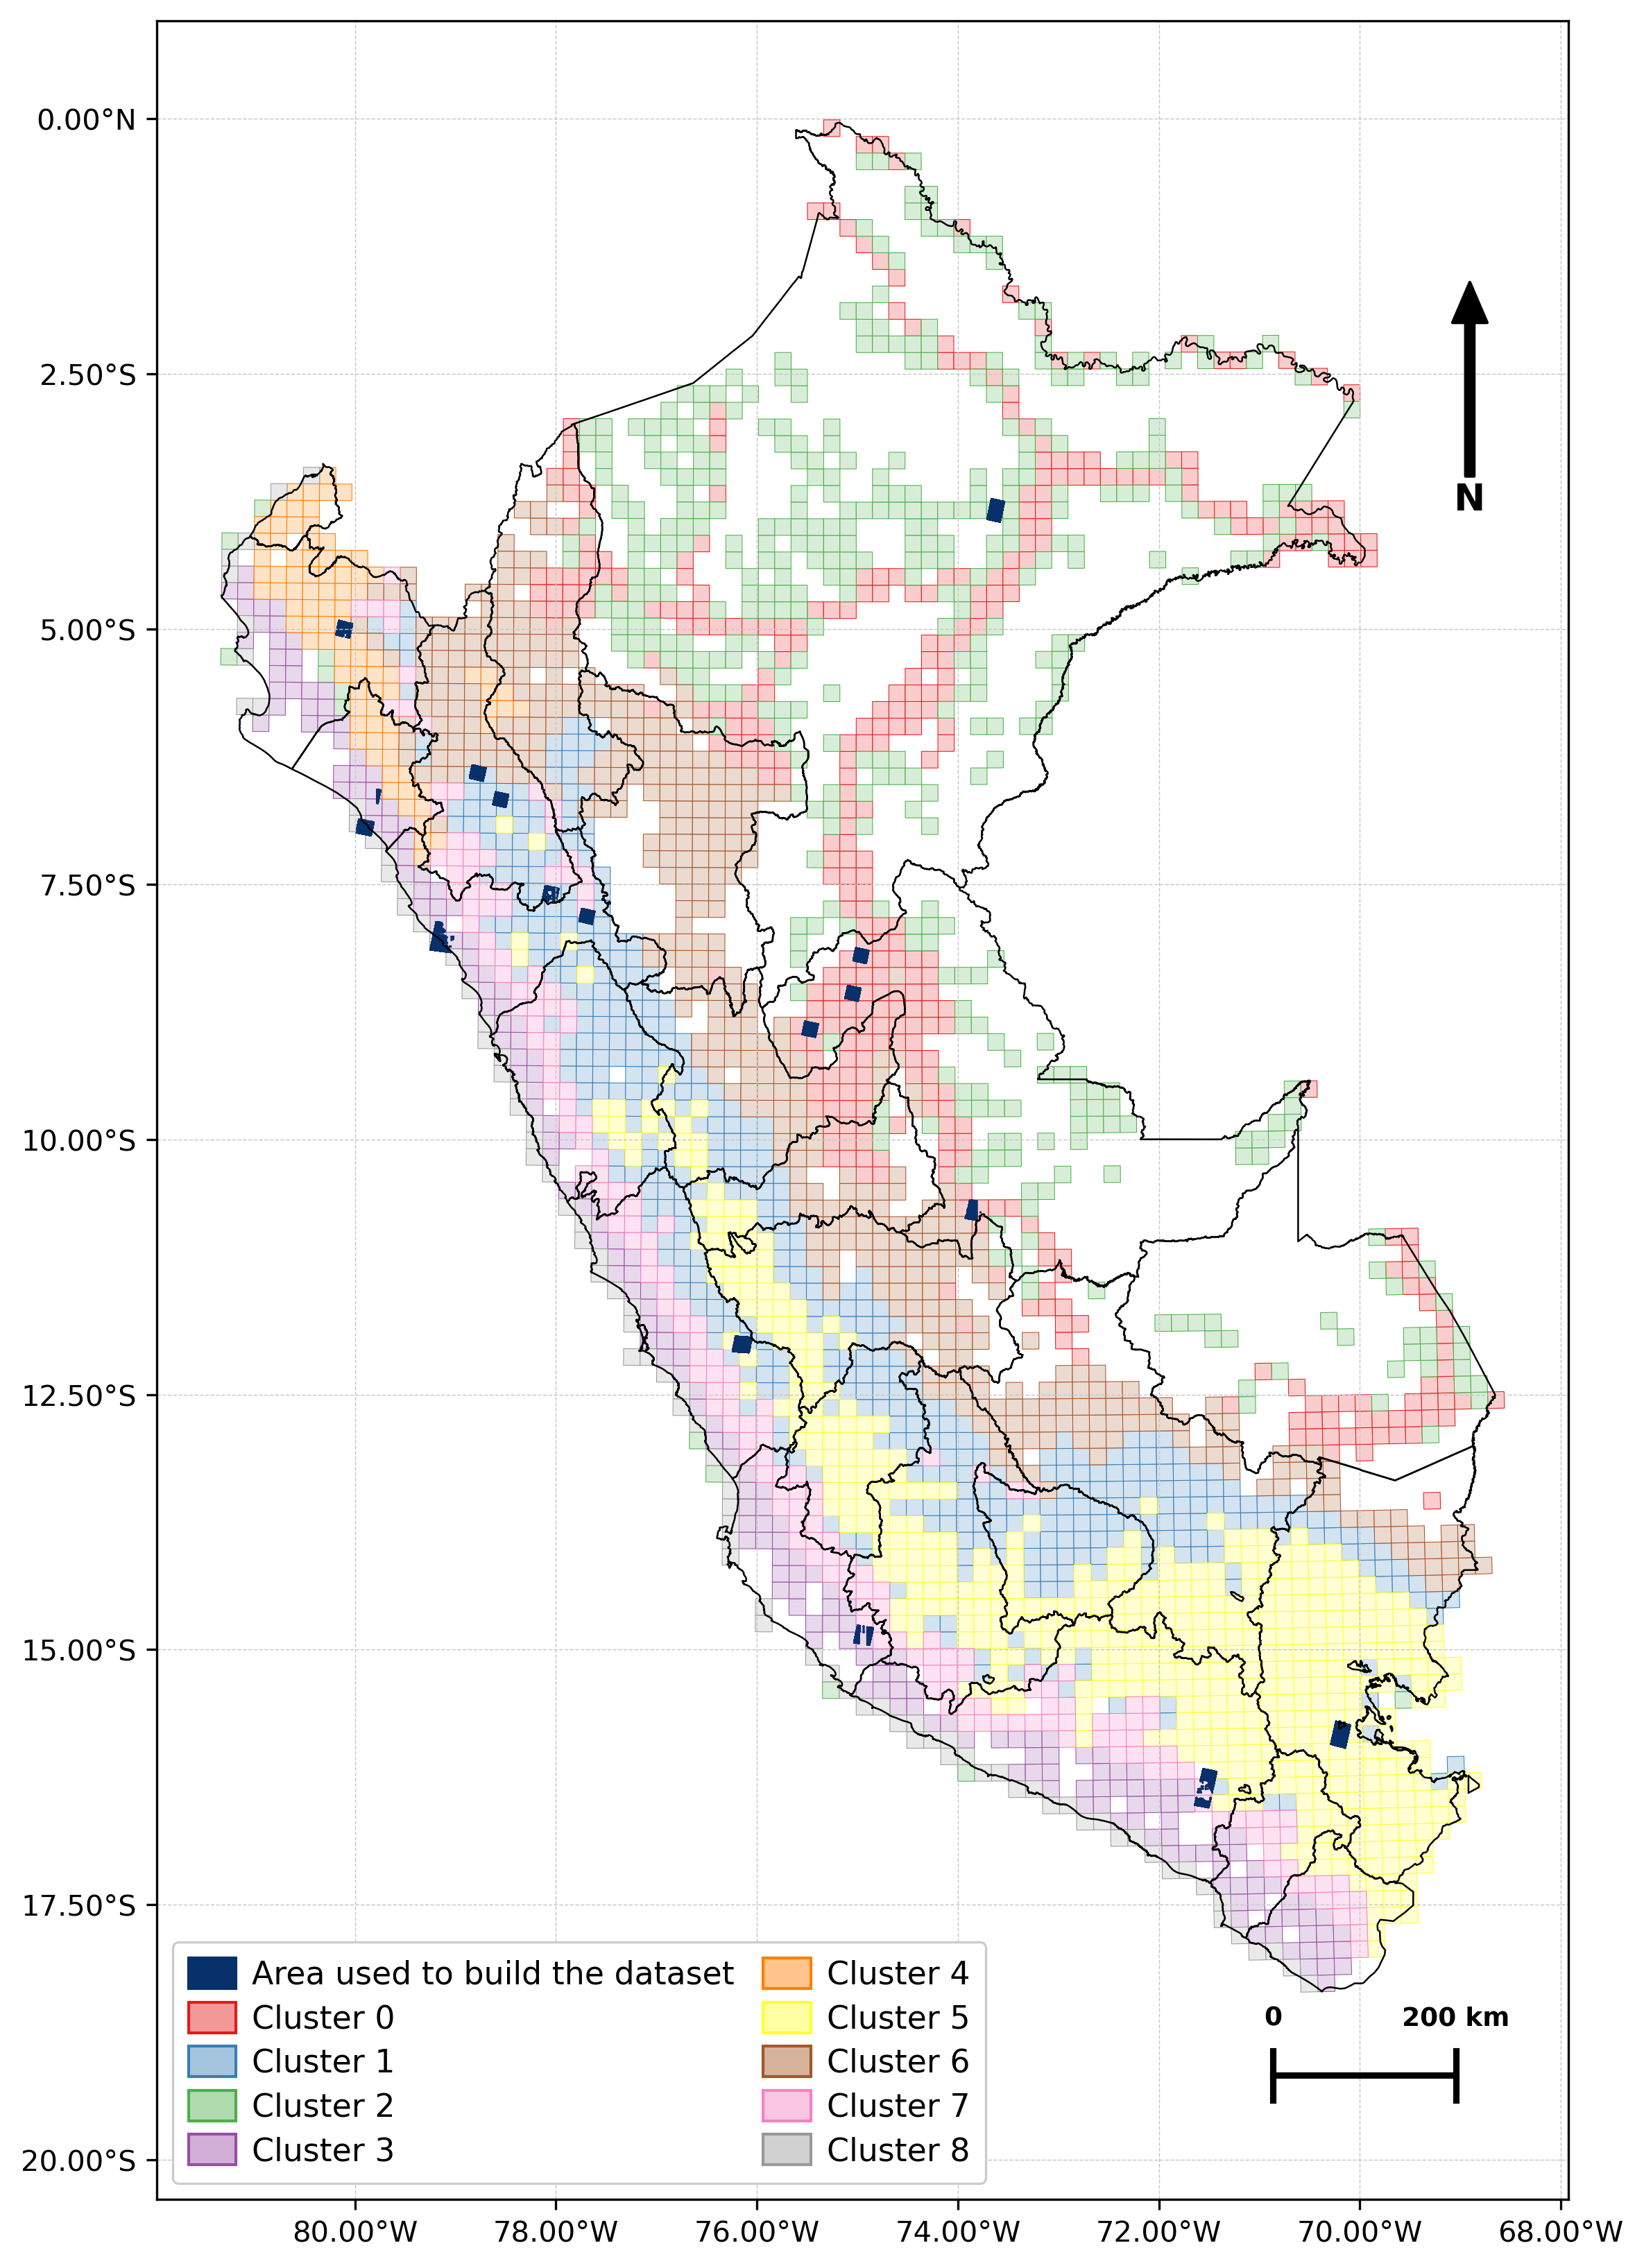

In [31]:
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors
import math

# Output directory for paper figures.
figure_dir = notebook_dir / "Outputs" / "Figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Plot in geographic coordinates so axes show latitude/longitude.
plot_crs = "EPSG:4326"

departments_plot = departments.to_crs(plot_crs)
clusters_plot = clustered_grid.to_crs(plot_crs)
footprints_plot = footprints_gdf.to_crs(plot_crs)

base_colors = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#66c2a5",
    "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
]

clusters = sorted(clusters_plot["cluster_id"].dropna().astype(int).unique())
cluster_color_map = {
    cluster: base_colors[index % len(base_colors)]
    for index, cluster in enumerate(clusters)
}

def blend_with_white(color, strength):
    rgb = mcolors.to_rgb(color)
    return tuple(strength * c + (1 - strength) for c in rgb)

fig, ax = plt.subplots(figsize=(9, 11), dpi=300)

# Territorial clusters with light solid colors, compatible with EPS.
for cluster in clusters:
    fill_color = blend_with_white(cluster_color_map[cluster], 0.22)

    clusters_plot[clusters_plot["cluster_id"] == cluster].plot(
        ax=ax,
        color=fill_color,
        edgecolor=cluster_color_map[cluster],
        linewidth=0.25,
    )

# Department borders only.
departments_plot.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.6,
)

# Areas used to build the dataset.
footprints_plot.plot(
    ax=ax,
    color="#08306B",
    edgecolor="#08306B",
    linewidth=0.45,
)

# Geographic coordinate labels.
def longitude_formatter(x, pos):
    hemisphere = "W" if x < 0 else "E"
    return f"{abs(x):.2f}°{hemisphere}"

def latitude_formatter(y, pos):
    hemisphere = "S" if y < 0 else "N"
    return f"{abs(y):.2f}°{hemisphere}"

ax.xaxis.set_major_formatter(FuncFormatter(longitude_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(latitude_formatter))

ax.grid(
    True,
    linestyle="--",
    linewidth=0.35,
    color="#c7c7c7",
)

# North arrow.
ax.annotate(
    "N",
    xy=(0.93, 0.88),
    xytext=(0.93, 0.78),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=3,
        headwidth=12,
        headlength=14,
    ),
)

# Scale bar, approximate because the map is in geographic coordinates.
scale_km = 200
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

center_lat = (ymin + ymax) / 2
km_per_degree_lon = 111.32 * math.cos(math.radians(center_lat))
scale_degrees = scale_km / km_per_degree_lon

# Scale bar on the lower-right side.
x_start = xmax - 0.08 * (xmax - xmin) - scale_degrees
y_start = ymin + 0.005 * (ymax - ymin)
tick_height = 0.012 * (ymax - ymin)

ax.plot(
    [x_start, x_start + scale_degrees],
    [y_start, y_start],
    color="black",
    linewidth=2.2,
)
ax.plot(
    [x_start, x_start],
    [y_start - tick_height, y_start + tick_height],
    color="black",
    linewidth=2.2,
)
ax.plot(
    [x_start + scale_degrees, x_start + scale_degrees],
    [y_start - tick_height, y_start + tick_height],
    color="black",
    linewidth=2.2,
)
ax.text(
    x_start,
    y_start + 1.8 * tick_height,
    "0",
    ha="center",
    va="bottom",
    fontsize=9,
    fontweight="bold",
)
ax.text(
    x_start + scale_degrees,
    y_start + 1.8 * tick_height,
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=9,
    fontweight="bold",
)

# Legend with dataset area and cluster colors.
legend_elements = [
    Patch(
        facecolor="#08306B",
        edgecolor="#08306B",
        label="Area used to build the dataset",
    )
]

legend_elements += [
    Patch(
        facecolor=blend_with_white(cluster_color_map[cluster], 0.45),
        edgecolor=cluster_color_map[cluster],
        label=f"Cluster {cluster}",
    )
    for cluster in clusters
]

legend = ax.legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True,
    framealpha=1.0,
    fontsize=11,
    ncol=2,
    handlelength=1.5,
    handleheight=1.1,
    handletextpad=0.5,
    columnspacing=0.9,
    labelspacing=0.35,
    borderpad=0.5,
)

legend.get_frame().set_linewidth(0.8)

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

figure_path = figure_dir / "dataset_areas_clusters_paper_map.eps"
plt.savefig(figure_path, format="eps", dpi=300, bbox_inches="tight")
plt.show()